<a href="https://colab.research.google.com/github/AnnaZapototska/goit-colab-homeworks/blob/development/hw_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1

In [267]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import SpectralClustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score
import librosa
import librosa.display
import os
import zipfile
from urllib.request import urlretrieve
from IPython.display import Audio
import seaborn as sns

In [268]:
url = "https://github.com/karoldvl/ESC-50/archive/master.zip"
zip_file_path = "ESC-50-master.zip"
download_path = "./ESC-50-master/"
if not os.path.exists(download_path):
    urlretrieve(url, zip_file_path)
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(download_path)
    os.remove(zip_file_path)

df_file_path = os.path.join(download_path, "ESC-50-master/meta", "esc50.csv")
df = pd.read_csv(df_file_path)
df.head(5)


,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A


In [269]:
selected_df = df[df["category"].isin(["dog", "chirping_birds"])].copy()

print(f"\n Record counts: {len(selected_df)}")

selected_df.head(5)


 Record counts: 80


,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
14,1-110389-A-0.wav,1,0,dog,True,110389,A
157,1-30226-A-0.wav,1,0,dog,True,30226,A
158,1-30344-A-0.wav,1,0,dog,True,30344,A


In [270]:
def spectrogram(samples, sample_rate, stride_ms = 10.0, window_ms = 20.0, max_freq = None, eps = 1e-14):

    stride_size = int(0.001 * sample_rate * stride_ms)
    window_size = int(0.001 * sample_rate * window_ms)

    # Extract strided windows
    truncate_size = (len(samples) - window_size) % stride_size
    samples = samples[:len(samples) - truncate_size]
    nshape = (window_size, (len(samples) - window_size) // stride_size + 1)
    nstrides = (samples.strides[0], samples.strides[0] * stride_size)
    windows = np.lib.stride_tricks.as_strided(samples, shape = nshape, strides = nstrides)

    assert np.all(windows[:, 1] == samples[stride_size:(stride_size + window_size)])

    # Window weighting, squared Fast Fourier Transform (fft), scaling
    weighting = np.hanning(window_size)[:, None]

    fft = np.fft.rfft(windows * weighting, axis=0)
    fft = np.absolute(fft)
    fft = fft**2

    scale = np.sum(weighting**2) * sample_rate
    fft[1:-1, :] *= (2.0 / scale)
    fft[(0, -1), :] /= scale

    # Prepare fft frequency list
    freqs = float(sample_rate) / window_size * np.arange(fft.shape[0])

    # Compute spectrogram feature
    # ind = np.where(freqs <= max_freq)[0][-1] + 1
    specgram = np.log(fft[:, :] + eps)
    return specgram

In [271]:
def pooling_audio(mat, ksize, method='max', pad=False):
    '''Non-overlapping pooling on 2D or 3D data.

    <mat>: ndarray, input array to pool.
    <ksize>: tuple of 2, kernel size in (ky, kx).
    <method>: str, 'max for max-pooling,
                   'mean' for mean-pooling.
    <pad>: bool, pad <mat> or not. If no pad, output has size
           n//f, n being <mat> size, f being kernel size.
           if pad, output has size ceil(n/f).

    Return <result>: pooled matrix.
    '''

    m, n = mat.shape[:2]
    ky,kx=ksize

    _ceil=lambda x,y: int(np.ceil(x/float(y)))

    if pad:
        ny=_ceil(m,ky)
        nx=_ceil(n,kx)
        size=(ny*ky, nx*kx)+mat.shape[2:]
        mat_pad=np.full(size,np.nan)
        mat_pad[:m,:n,...]=mat
    else:
        ny=m//ky
        nx=n//kx
        mat_pad=mat[:ny*ky, :nx*kx, ...]

    new_shape=(ny,ky,nx,kx)+mat.shape[2:]

    if method=='max':
        result=np.nanmax(mat_pad.reshape(new_shape),axis=(1,3))
    else:
        result=np.nanmean(mat_pad.reshape(new_shape),axis=(1,3))

    return result


In [272]:
audio_dir = os.path.join(download_path, "ESC-50-master", "audio")

data = []
for _, row in selected_df.iterrows():

    audio_path = os.path.join(audio_dir, row["filename"])
    y, sr = librosa.load(audio_path, sr=None)

    spect_matrix = spectrogram(y, sr)
    pooled_matrix = pooling_audio(spect_matrix, ksize=(10,10))
    feature = pooled_matrix.flatten()

    data.append({
        "filename": row["filename"],
        "category": row["category"],
        "spectrogram": spect_matrix,
        "pooled": pooled_matrix,
        "feature": feature
    })

In [273]:
len(data)

80

In [274]:
def spect_show(matrix, title):
    plt.figure(figsize=(8, 4))
    plt.imshow(matrix, cmap='viridis', interpolation='nearest', aspect='auto')
    plt.colorbar()
    plt.title(title)
    plt.xlabel("Frame number")
    plt.ylabel("Frequency")
    plt.show()

## Show the spectrogram

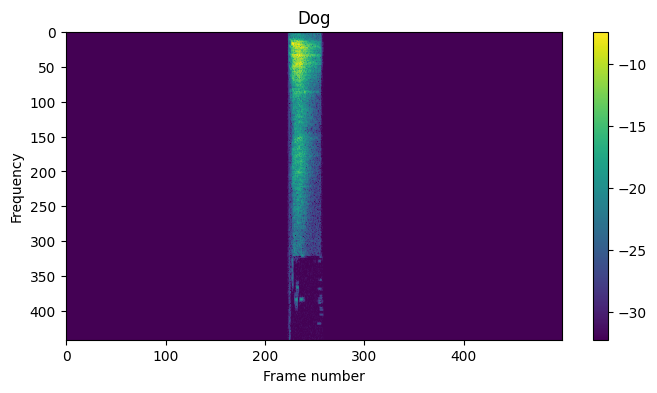

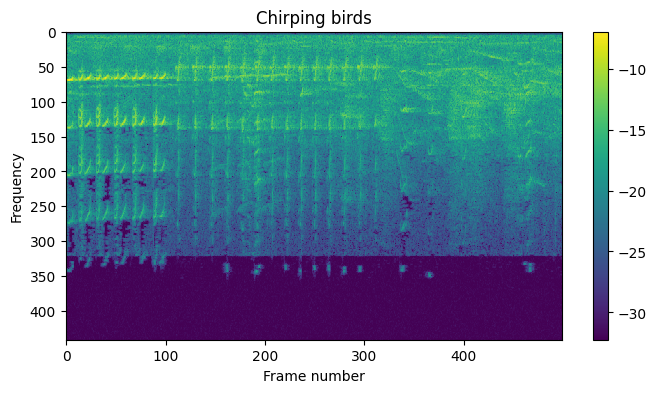

In [275]:
for item in data:
    if item["category"] == "dog":
        spect_show(item["spectrogram"], "Dog")
        break

for item in data:
    if item["category"] == "chirping_birds":
        spect_show(item["spectrogram"], "Chirping birds")
        break

## Show the pooled matrix

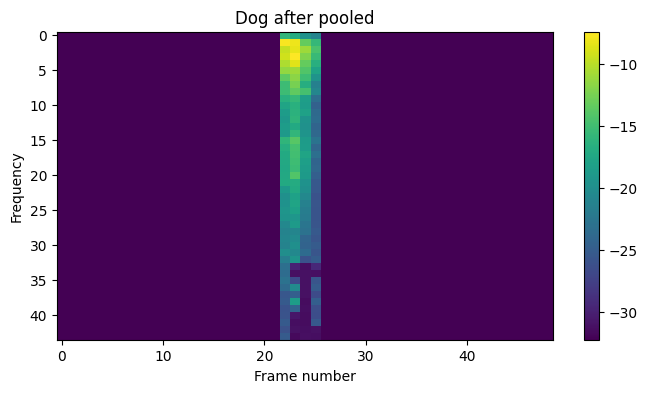

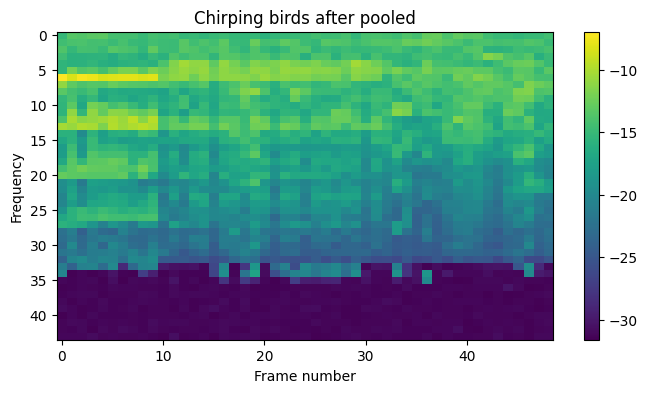

In [276]:
for item_p in data:
    if item_p["category"] == "dog":
        spect_show(item_p["pooled"], "Dog after pooled")
        break

for item_p in data:
    if item_p["category"] == "chirping_birds":
        spect_show(item_p["pooled"], "Chirping birds after pooled")
        break

In [277]:
# Compared together to make a visual understanding
def compare_spectrograms(original, pooled, title):

    fig, ax = plt.subplots(1, 2, figsize=(14,4))

    ax[0].imshow(original, aspect='auto', origin='lower', cmap='viridis')
    ax[0].set_title("Original")

    ax[1].imshow(pooled, aspect='auto', origin='lower', cmap='viridis')
    ax[1].set_title("After pooling")

    plt.suptitle(title)
    plt.show()

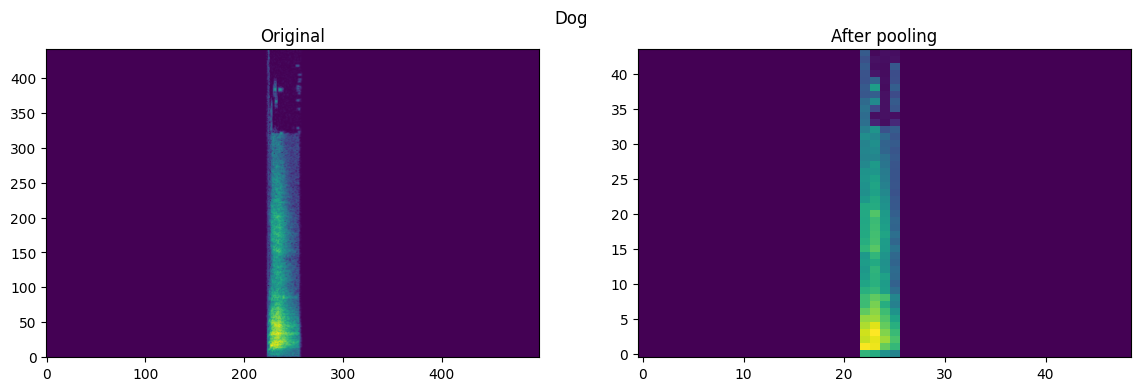

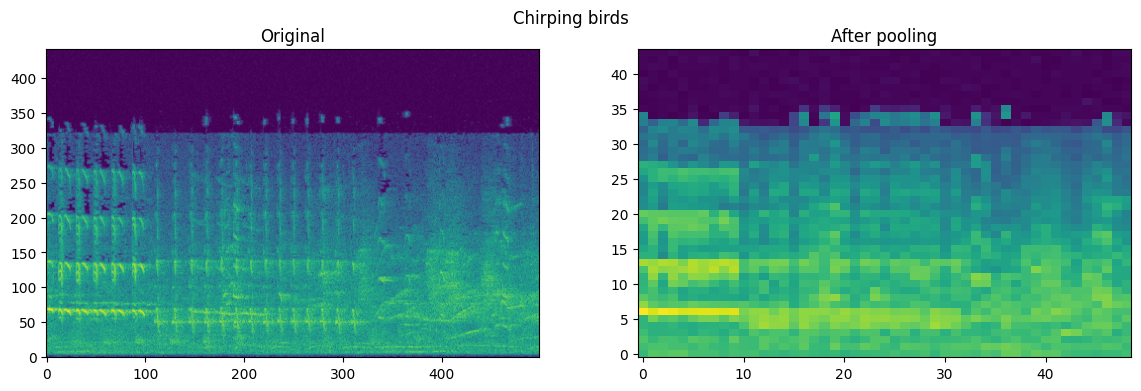

In [278]:
for item in data:
    if item["category"] == "dog":
        compare_spectrograms(
            item["spectrogram"],
            item["pooled"],
            "Dog"
        )
        break

for item in data:
    if item["category"] == "chirping_birds":
        compare_spectrograms(
            item["spectrogram"],
            item["pooled"],
            "Chirping birds"
        )
        break

In [279]:
print(spect_matrix.shape)
print(spect_matrix.flatten().shape)

print(pooled_matrix.shape)
print(pooled_matrix.flatten().shape)

(442, 499)
(220558,)
(44, 49)
(2156,)


In [280]:
print(data[0]["pooled"].shape)
print(data[0]["feature"].shape)

X = np.array([item["feature"] for item in data])

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
print(X_scaled.shape)

(44, 49)
(2156,)
(80, 2156)


In [281]:
spectral = SpectralClustering(
    n_clusters=2,
    affinity='nearest_neighbors',
    assign_labels='kmeans',
    random_state=42
)

predicted_labels = spectral.fit_predict(X_scaled)

selected_df["predicted_label"] = predicted_labels
selected_df.head()

,filename,fold,target,category,esc10,src_file,take,predicted_label
0,1-100032-A-0.wav,1,0,dog,True,100032,A,0
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A,1
14,1-110389-A-0.wav,1,0,dog,True,110389,A,0
157,1-30226-A-0.wav,1,0,dog,True,30226,A,0
158,1-30344-A-0.wav,1,0,dog,True,30344,A,0


In [282]:
true_labels = selected_df["category"].map({
    "dog": 0,
    "chirping_birds": 1
})

ari = adjusted_rand_score(
    true_labels,
    predicted_labels
)

print(f"ARI = {ari:.3f}")

ARI = 0.240


In [283]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [284]:
pd.crosstab(
    selected_df["category"],
    selected_df["predicted_label"]
)

predicted_label,0,1
category,,
chirping_birds,11,29
dog,31,9


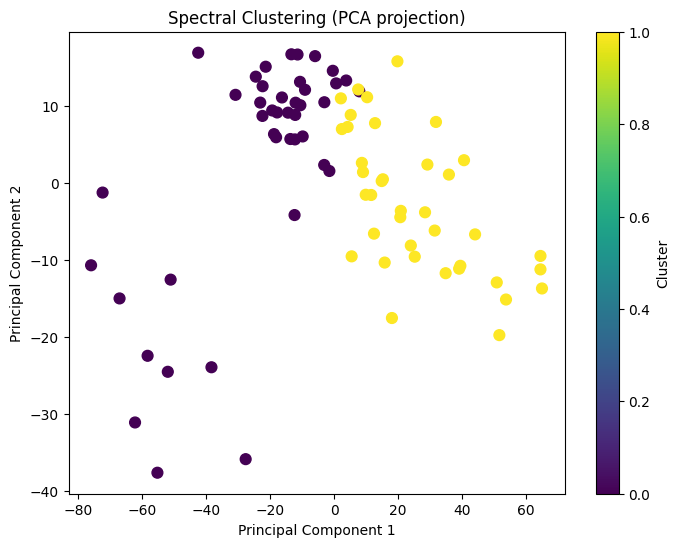

In [285]:
confusion = pd.crosstab(
    selected_df["category"],
    selected_df["predicted_label"]
)

plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=predicted_labels,
    cmap="viridis",
    s=60
)

plt.title("Spectral Clustering (PCA projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(label="Cluster")
plt.show()

# Summary

Although the clustering results are not perfect, they provide valuable insights into the extracted spectral features and demonstrate that Fourier-based representations capture meaningful information about different sound categories.

Most of the dog sounds were grouped into one cluster (31 out of 40), while most of the chirping bird sounds were grouped into the other cluster (29 out of 40).
There were 20 misclassified recordings: 9 dog recordings were assigned to the bird cluster, and 11 bird recordings were assigned to the dog cluster.

This indicates that the spectral features obtained using the Fourier transform allow for a fairly good separation of different types of sounds, although due to the similarity of individual signals or the presence of noise, the clustering is not ideal.